In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
from sklearn.datasets import load_diabetes
df = load_diabetes()

In [4]:
#check the dataset
diabetes_df = pd.DataFrame(df.data, columns=df.feature_names)


In [5]:
diabetes_df.shape

(442, 10)

In [6]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [7]:
diabetes_df['TARGET'] = df.target
# To add these target values as a new column to your diabetes_df DataFrame, you should use diabetes_df['TARGET'] = df.target.
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [8]:
#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(diabetes_df.drop('TARGET', axis=1), diabetes_df['TARGET'], test_size=0.2, random_state=42)

In [9]:
coefs = []                                      # Empty list to store coefficients for each alpha

r2_scores = []                                  # Empty list to store R² score for each alpha

# Define the new, expanded list of alpha values
alphas = [0, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

for i in alphas:                       # Loop through different alpha values

    # name_of your_model = Lasso(alpha=value)              | Lasso() → creates a Lasso Regression model
    reg = Lasso(alpha=i)                             # Create a Lasso Regression model with alpha = i

    # name_of_you_model.fit(X_train, y_train)
    reg.fit(X_train, y_train)                   # Train the Lasso model using training data


    coefs.append(reg.coef_.tolist())            # Get the model coefficients and store them in coefs



    # y_pred = name_of your_model.predict(X_test)        # after trainning the model we have to predict the model so that we calculate the performance of model -> so we have to predict y on the basis of trained mmodel through x
    y_pred = reg.predict(X_test)                # Predict the target values using test data

    r2_scores.append(r2_score(y_test, y_pred))  # Calculate R² score and store it in r2_scores

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.063e+05, tolerance: 2.145e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

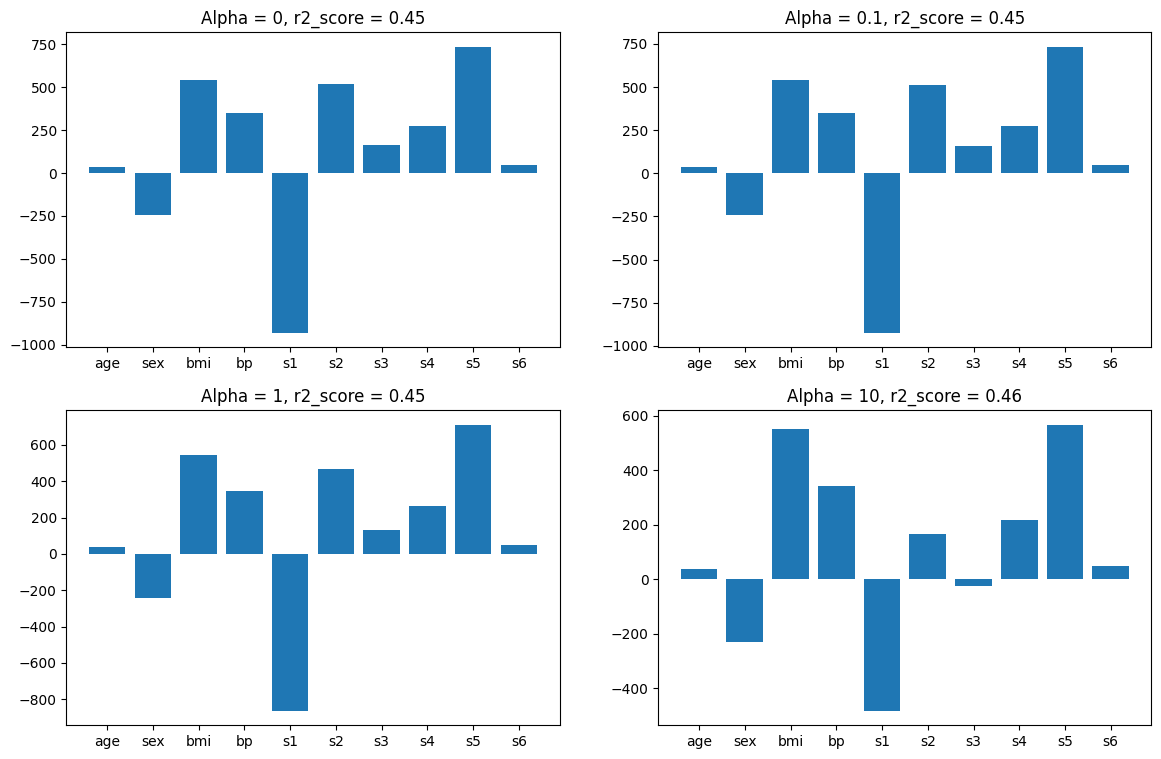

In [10]:



plt.figure(figsize=(14, 9))                       # Create a figure of width 14 and height 9


plt.subplot(221)                                  # Create subplot 1: 2 rows × 2 columns → position 1

plt.bar(df.feature_names, coefs[0])             # Create bar chart using feature names and coefficients
                                                  # coefs[0] = coefficients when alpha = 0

plt.title('Alpha = 0, r2_score = {}'.format(      # Set title of the first subplot
    round(r2_scores[0], 2)                        # Round the R² score to 2 decimal places
))


plt.subplot(222)                                  # Create subplot 2: position 2

plt.bar(df.feature_names, coefs[1])             # Bar chart of coefficients for alpha = 0.1

plt.title('Alpha = 0.1, r2_score = {}'.format(    # Set title
    round(r2_scores[1], 2)                        # Get R² score for alpha = 0.1 and round to 2 decimals
))


plt.subplot(223)                                  # Create subplot 3: position 3

plt.bar(df.feature_names, coefs[2])             # Bar chart of coefficients for alpha = 1

plt.title('Alpha = 1, r2_score = {}'.format(      # Set title
    round(r2_scores[2], 2)                        # Get R² score for alpha = 1
))


plt.subplot(224)                                  # Create subplot 4: position 4

plt.bar(df.feature_names, coefs[3])             # Bar chart of coefficients for alpha = 10

plt.title('Alpha = 10, r2_score = {}'.format(     # Set title
    round(r2_scores[3], 2)                        # Get R² score for alpha = 10
))


plt.show()                                        # Display all four subplots

In [ ]:
''' Interpreting the graphs for feature selection:

Alpha = 0: This is equivalent to standard Linear Regression (no regularization). All features have non-zero coefficients, meaning the model is using all available features to make predictions.

Alpha = 0.1: You'll notice that some coefficients have become very small or have been shrunk to zero (or very close to zero). This indicates that Lasso has started to identify less important features and reduce their impact on the model, or remove them entirely.

Alpha = 1: With a slightly larger alpha, more coefficients have been driven to zero. This signifies a more aggressive feature selection. The model is now simpler, relying on fewer, presumably more important, features.

Alpha = 10: At this high alpha value, almost all coefficients have been forced to zero. This indicates that the regularization is too strong, and the model is likely too simplistic, potentially leading to underfitting (as seen by the very low R-squared score). '''

In [12]:
import numpy as np
import pandas as pd

# Convert the list of coefficients into a NumPy array
input_array = np.array(coefs)

# alphas is now defined in the previous cell and used for the Lasso loop
# Ensure coefs has the same number of elements as alphas

# Convert the NumPy array into a Pandas DataFrame
# Each column represents one feature
# df.feature_names contains the names of the features from the original loaded dataset
coef_df = pd.DataFrame(
    input_array,
    columns=df.feature_names
)


# Add the alpha values as a new column called 'alpha'
# Each row corresponds to one alpha value used in Lasso
coef_df['alpha'] = alphas


# Make 'alpha' the index of the DataFrame
# This makes it easier to see which coefficients belong to which alpha
coef_df = coef_df.set_index('alpha')
coef_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,37.904021,-241.964362,542.428759,347.703844,-931.488838,518.062271,163.419980,275.317901,736.198856,48.670657
0.0001,37.891667,-241.878244,542.524544,347.624893,-924.832045,513.033268,160.224210,274.036385,733.762619,48.690013
0.0010,37.780431,-241.103200,543.386372,346.914418,-864.934721,467.782935,131.468467,262.504646,711.841733,48.864159
0.0100,35.347451,-231.906664,551.303242,341.313469,-483.567140,165.990532,-25.834899,216.875803,566.815003,49.702475
0.1000,0.000000,-152.664779,552.697775,303.365158,-81.365007,-0.000000,-229.255776,0.000000,447.919525,29.642617
1.0000,0.000000,-0.000000,413.431848,34.830515,0.000000,0.000000,-0.000000,0.000000,258.152894,0.000000
10.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
100.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
1000.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000


In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# --------------------------------------------------
# 1. Separate features and target
# --------------------------------------------------

X = df.data
y = df.target


# --------------------------------------------------
# 2. Split the dataset
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# --------------------------------------------------
# 3. Standardize the features
# --------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# --------------------------------------------------
# 4. Different alpha values
# --------------------------------------------------

alphas = [
    0.0001,
    0.001,
    0.01,
    0.1,
    1,
    10,
    100
]


# --------------------------------------------------
# 5. Lists to store Bias², Variance and Total Error
# --------------------------------------------------

bias_squared = []
variance = []
total_error = []


# Number of times we train the model
n_iterations = 100


# --------------------------------------------------
# 6. Loop through every alpha
# --------------------------------------------------

for alpha in alphas:

    predictions = []


    # ----------------------------------------------
    # Train the model many times
    # ----------------------------------------------

    for i in range(n_iterations):

        # Randomly select training samples
        indices = np.random.choice(
            len(X_train),
            size=len(X_train),
            replace=True
        )

        X_sample = X_train[indices]
        y_sample = y_train[indices]


        # Create Lasso model
        model = Lasso(alpha=alpha)


        # Train model
        model.fit(X_sample, y_sample)


        # Predict on the SAME test data
        y_pred = model.predict(X_test)


        # Store predictions
        predictions.append(y_pred)


    # Convert predictions to NumPy array
    predictions = np.array(predictions)


    # ----------------------------------------------
    # Mean prediction
    # ----------------------------------------------

    mean_prediction = np.mean(predictions, axis=0)


    # ----------------------------------------------
    # Bias²
    # ----------------------------------------------

    bias = np.mean(
        (mean_prediction - y_test) ** 2
    )

    bias_squared.append(bias)


    # ----------------------------------------------
    # Variance
    # ----------------------------------------------

    var = np.mean(
        np.var(predictions, axis=0)
    )

    variance.append(var)


    # ----------------------------------------------
    # Total error
    # ----------------------------------------------

    error = bias + var

    total_error.append(error)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.215e+02, tolerance: 2.094e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.365e+03, tolerance: 2.013e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.380e+02, tolerance: 2.089e

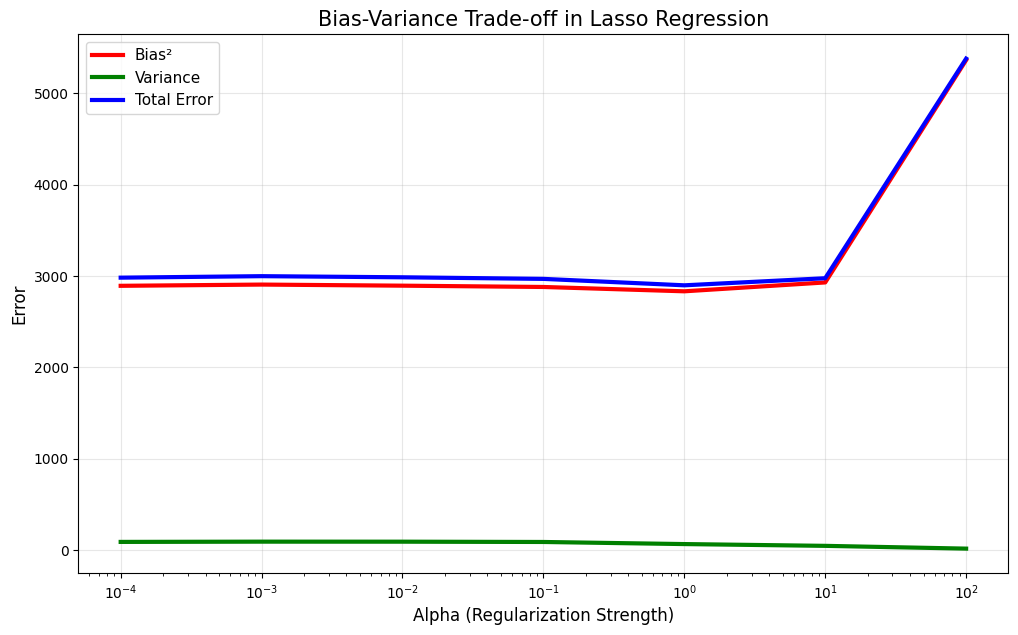

In [15]:
plt.figure(figsize=(12, 7))


# Bias² curve
plt.plot(
    alphas,
    bias_squared,
    'r-',
    linewidth=3,
    label='Bias²'
)


# Variance curve
plt.plot(
    alphas,
    variance,
    'g-',
    linewidth=3,
    label='Variance'
)


# Total error curve
plt.plot(
    alphas,
    total_error,
    'b-',
    linewidth=3,
    label='Total Error'
)


# X-axis on logarithmic scale
plt.xscale('log')


# Labels
plt.xlabel('Alpha (Regularization Strength)', fontsize=12)
plt.ylabel('Error', fontsize=12)


# Title
plt.title(
    'Bias-Variance Trade-off in Lasso Regression',
    fontsize=15
)


# Show legend
plt.legend(fontsize=11)


# Grid
plt.grid(True, alpha=0.3)


# Display graph
plt.show()

In [17]:
optimal_alpha_index = np.argmin(total_error)
optimal_alpha = alphas[optimal_alpha_index]

print(f"The alpha value that minimizes the total error is: {optimal_alpha}")

The alpha value that minimizes the total error is: 1
